In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql

# Fil 03: KPI-analys och Affärsinsikter
I den här sista delen av projektet analyserar vi den städade datan från Gröna Gården. Vi har nu en databas med sentimentanalys (BERT) och beräknade leveranstider.


In [2]:

# 1. Anslut till databasen
conn = sql.connect('../gronagarden_data_cleaned.db')

# 2. Hämta huvuddatan (den med alla ordrar och BERT-sentiment)
df = pd.read_sql('SELECT * FROM orders', conn)

# 3. Hämta valideringsdatan (för att visa hur BERT skötte sig på testfilen)
df_val = pd.read_sql('SELECT * FROM validation_results', conn)

# 4. Stäng anslutningen
conn.close()

# 5. Fixa datum i huvud-df:n
df['orderdatum'] = pd.to_datetime(df['orderdatum'])


## 3.1 Analys av leveransprestanda per zon
För att förstå om kundernas missnöje beror på logistiska faktorer undersöker vi här den genomsnittliga leveranstiden i dagar för varje zon. 


/var/folders/29/3kf793v13_j58pg81t38xr_m0000gn/T/ipykernel_13212/1677432297.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='leveranszon', y='leveranstid_dagar', data=df, ci=None)


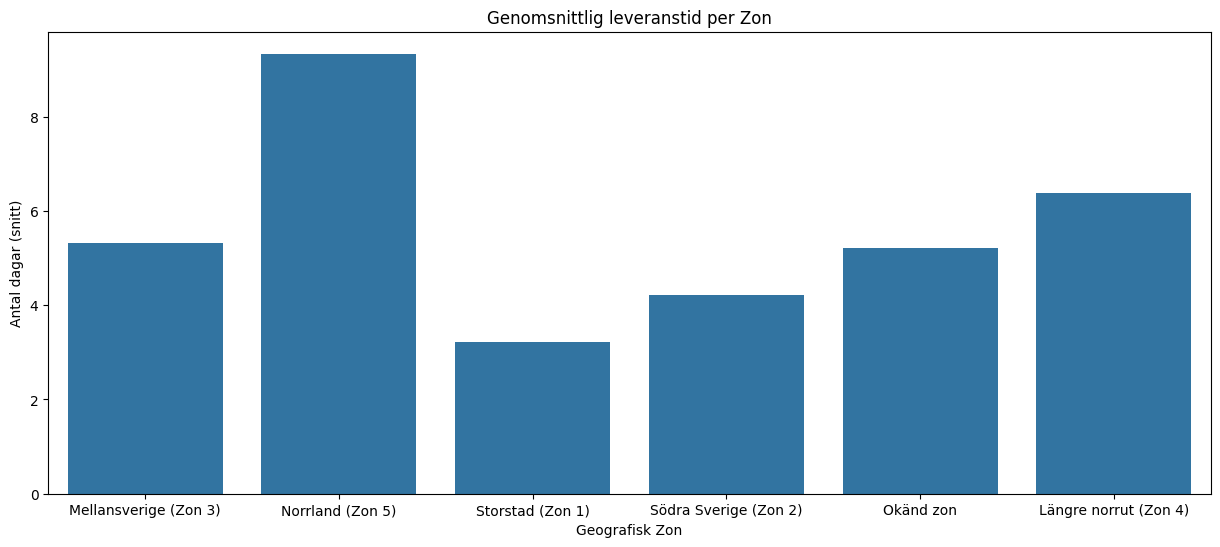

In [3]:

# Skapa grafen
plt.figure(figsize=(15, 6))
sns.barplot(x='leveranszon', y='leveranstid_dagar', data=df, ci=None)
# Lägg till titlar
plt.title('Genomsnittlig leveranstid per Zon')
plt.xlabel('Geografisk Zon')
plt.ylabel('Antal dagar (snitt)')
plt.show()

## 3.2 Visualisering av kundnöjdhet per zon
Här analyserar vi fördelningen av positiva, neutrala och negativa recensioner för de olika leveranszonerna. Genom att använda vår BERT-baserade sentimentanalys kan vi se bortom siffrorna och förstå den faktiska kundupplevelsen.

Vi har exkluderat rader med "Ingen recension" för att fokusera på den aktiva feedbacken.


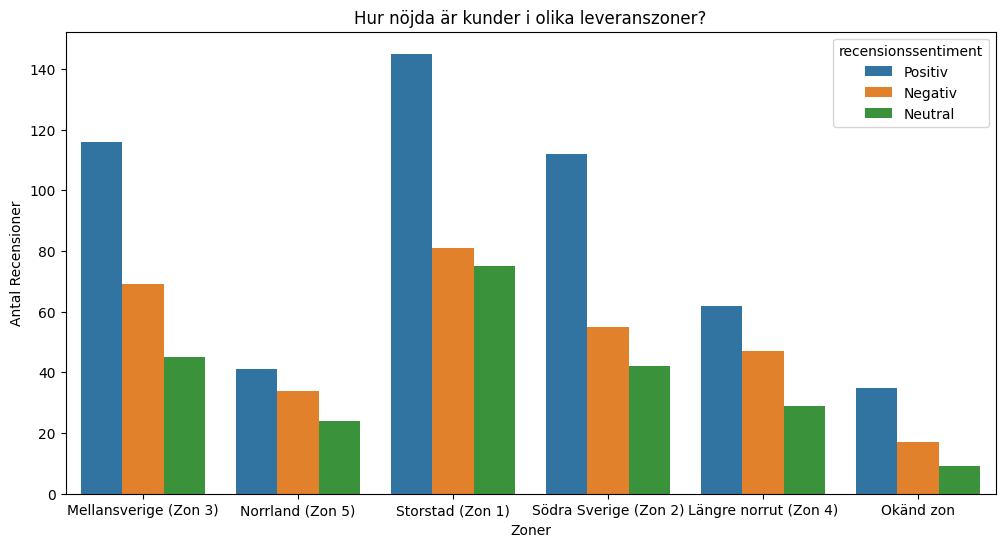

In [4]:
#Skapa graf för folk i olika zon som visar hur nöjda de är
plt.figure(figsize=(12, 6))
#Tog bort 'Ingen recension' från grafen
sns.countplot(data=df[df['recensionssentiment'] != 'Ingen recension'], x='leveranszon', hue='recensionssentiment')
              

plt.title('Hur nöjda är kunder i olika leveranszoner?')
plt.xlabel('Zoner')
plt.ylabel('Antal Recensioner')
plt.show()

## 3.3 Korrelation mellan Sifferbetyg och AI-sentiment
För att säkerställa att vår BERT-modell har tolkat recensionerna korrekt jämför vi här de manuella sifferbetygen (1-5) med modellens förutsedda sentiment.


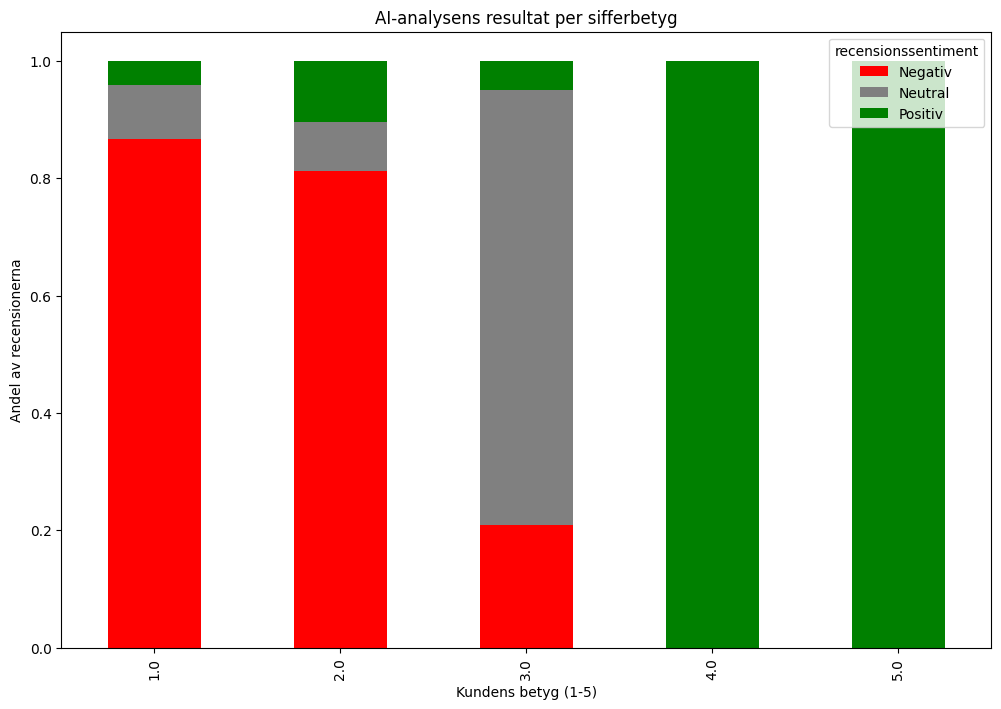

In [5]:
# 1. Förbered data (ta bort de utan recension för att få en ren graf)
df_plot = df[df['recensionssentiment'] != 'Ingen recension']

# 2. Skapa grafen
# Vi grupperar på betyg och ser hur sentimentet fördelas i procent (normalize=True)
df_plot.groupby('betyg')['recensionssentiment'].value_counts(normalize=True).unstack().plot(
    kind='bar', 
    stacked=True, 
    color=['red', 'gray', 'green'],
    figsize=(12, 8)
)
plt.title('AI-analysens resultat per sifferbetyg')
plt.xlabel('Kundens betyg (1-5)')
plt.ylabel('Andel av recensionerna')
plt.show()